# Bandit Problem

In [21]:
class Bandit:
    def __init__(self, mean=0, stddev=1):
        self.__mean = mean
        self.__stddev = stddev

    '''This method simulates pulling the lever of the bandit and returns the reward'''
    def pullLever(self):
        return np.random.normal(self.__mean, self.__stddev)

In [22]:
# imports
import random
import numpy as np
import matplotlib.pyplot as plt

A bandit is one option (or “arm”) you can choose, where the reward you get is uncertain and must be learned by trying it out.
In multi-armed bandits, you repeatedly pick among several such uncertain options to find which one pays best.

A list of ten bandit objects initialized in the list...

In [23]:
bandits = [Bandit(random.random()*4-2) for _ in range(10)]

To generate reward from that bandit, use the pullLever() command

In [24]:
bandits[0].pullLever()

0.2810915776100574

## Greedy algorithm Implementation

In [25]:
def run_greedy():
    average=np.zeros(n)
    tries=np.zeros(n)
    rewards=[]

    for _ in range(times):
        chosenLever=np.argmax(average)
        reward=bandits[chosenLever].pullLever()
        rewards.append(reward)
        tries[chosenLever]+=1
        average[chosenLever]=average[chosenLever]+(reward-average[chosenLever])/tries[chosenLever]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases. and display that image below.

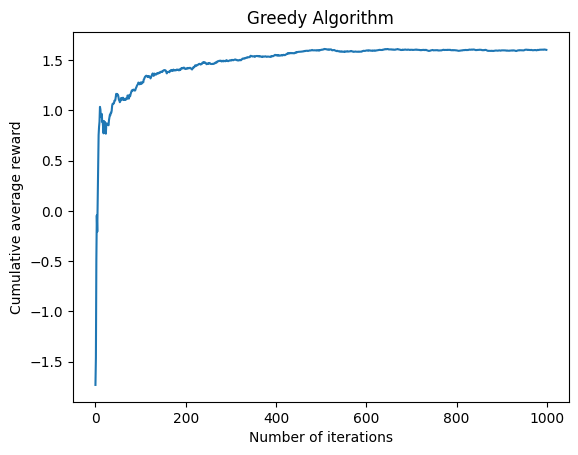

In [26]:
import numpy as np
import matplotlib.pyplot as plt
n=len(bandits)
times=1000
rewards=run_greedy()
cumul_avg=[]
sum=0
for i in range(len(rewards)):
  sum+=rewards[i]
  cumul_avg.append(sum/(i+1))
plt.plot(cumul_avg)
plt.xlabel("Number of iterations")
plt.ylabel("Cumulative average reward")
plt.title("Greedy Algorithm")
plt.show()

## $\epsilon$-greedy Algorithm

In [27]:
def run_epsilon_greedy(epsilon):
  n=len(bandits)
  average=np.zeros(n)
  tries=np.zeros(n)
  rewards=[]
  for _ in range(times):
      x=random.random()
      if x<epsilon:
          chosenLever=random.randrange(n)
      else:
          chosenLever=np.argmax(average)
      reward=bandits[chosenLever].pullLever()
      rewards.append(reward)
      tries[chosenLever]+=1
      average[chosenLever]+=(reward-average[chosenLever])/tries[chosenLever]
  return rewards

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

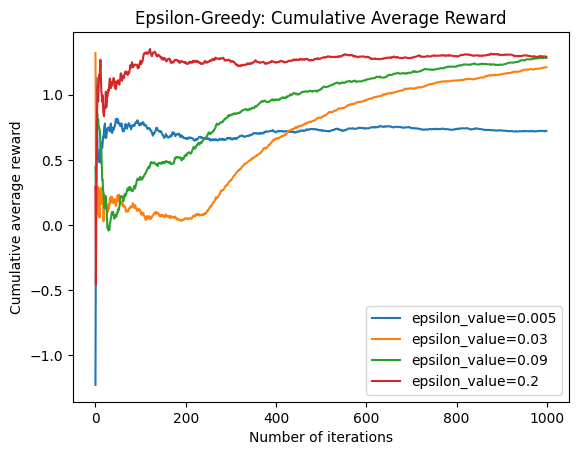

In [28]:
epsilons=[0.005, 0.03, 0.09, 0.2]
for epsilon in epsilons:
    rewards=run_epsilon_greedy(epsilon)
    cumul_avg=[]
    sum=0
    for i in range(len(rewards)):
        sum+=rewards[i]
        cumul_avg.append(sum/(i+1))
    plt.plot(cumul_avg, label=f"epsilon_value={epsilon}")
plt.xlabel("Number of iterations")
plt.ylabel("Cumulative average reward")
plt.title("Epsilon-Greedy: Cumulative Average Reward")
plt.legend()
plt.show()

## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

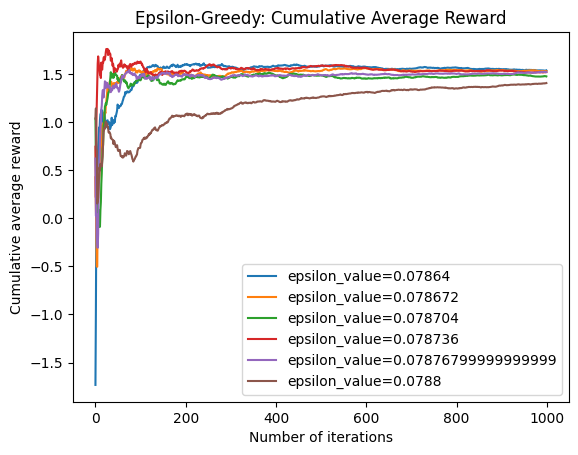

In [29]:
epsilons=np.linspace(0.07864, 0.0788, 6)
for epsilon in epsilons:
    rewards=run_epsilon_greedy(epsilon)
    cumul_avg=[]
    sum=0
    for i in range(len(rewards)):
        sum+=rewards[i]
        cumul_avg.append(sum/(i+1))
    plt.plot(cumul_avg, label=f"epsilon_value={epsilon}")
plt.xlabel("Number of iterations")
plt.ylabel("Cumulative average reward")
plt.title("Epsilon-Greedy: Cumulative Average Reward")
plt.legend()
plt.show()

Optimal value of epsilon is 0.078704

## Optimistic Initial Values

In [30]:
def run_optimistic_greedy():
    n=len(bandits)
    count=1
    average=np.ones(n)*q1
    tries=np.ones(n)*count
    rewards=[]
    for _ in range(times):
        chosenLever = np.argmax(average)
        reward = bandits[chosenLever].pullLever()
        rewards.append(reward)
        tries[chosenLever] += 1
        average[chosenLever]+=(reward-average[chosenLever])/tries[chosenLever]

    return rewards


Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$ and try to compare which is better.

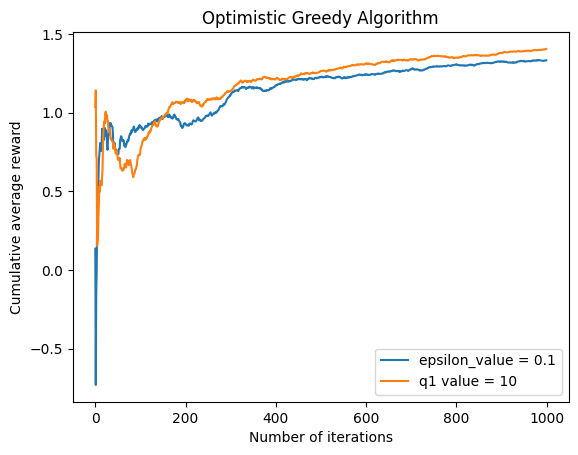

In [31]:
n=len(bandits)
times=1000
epsilon=0.1
q1=10
rewards1=run_epsilon_greedy(epsilon)
cumul_avg=[]
sum=0
for i in range(len(rewards1)):
    sum+=rewards1[i]
    cumul_avg.append(sum/(i+1))
plt.plot(cumul_avg, label=f"epsilon_value = {epsilon}")
plt.xlabel("Number of iterations")
plt.ylabel("Cumulative average reward")
plt.title("Epsilon-Greedy: Cumulative Average Reward")
plt.legend()
rewards2=run_optimistic_greedy()
cumul_avg=[]
sum=0
for i in range(len(rewards2)):
  sum+=rewards[i]
  cumul_avg.append(sum/(i+1))
plt.plot(cumul_avg, label=f"q1 value = {q1}")
plt.xlabel("Number of iterations")
plt.ylabel("Cumulative average reward")
plt.title("Optimistic Greedy Algorithm")
plt.legend()
plt.show()

## Upper Confidence Bound (UCB)

In [32]:
def run_ucb(c):
  n=len(bandits)
  average=np.zeros(n)
  tries=np.zeros(n)
  rewards=[]

  for i in range(n):
    reward=bandits[i].pullLever()
    rewards.append(reward)
    tries[i]+=1
    average[i]=reward

  for _ in range(n, times):
    ucb=[]
    for i in range(n):
      ucb_bonus=c*np.sqrt(np.log(_+1)/tries[i])
      ucb.append(average[i]+ucb_bonus)
    chosenLever=np.argmax(ucb)
    reward=bandits[chosenLever].pullLever()
    rewards.append(reward)
    tries[chosenLever]+=1
    average[chosenLever]=average[chosenLever]+(reward-average[chosenLever])/tries[chosenLever]
  return rewards

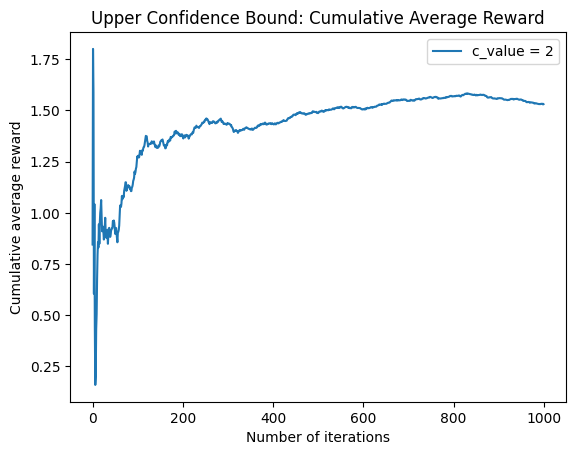

In [33]:
times=1000
c=2
rewards=run_ucb(c)
cumul_avg=[]
sum=0
for i in range(len(rewards)):
    sum+=rewards[i]
    cumul_avg.append(sum/(i+1))
plt.plot(cumul_avg, label=f"c_value = {c}")
plt.xlabel("Number of iterations")
plt.ylabel("Cumulative average reward")
plt.title("Upper Confidence Bound: Cumulative Average Reward")
plt.legend()
plt.show()